# Оптимизация портфеля
## 1. Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import apimoex
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime
import requests

Загружать данные будем с помощью **apimoex** для простоты. Есть также вариант собирать данные, например, с помощью **yfinance**, но в данном проекте я остановлюсь на [Московской бирже](https://www.moex.com/ru/aktsii).
В случае нашего портфеля, мы рассмотрим 10 следующих акций:
1. SBER (Сбербанк)
2. LKOH (Лукойл)
3. GAZP (ГАЗПРОМ ао)
4. YDEX (ЯНДЕКС)
5. T (Т-Техно ао)
6. PLZL (Полюс)
7. GMKN (ГМКНорНик)
8. TATN (Татнфт Зао)
9. NVTK (Новатэк ао)
10. VTBR (ВТБ ао)

Были взяты первые 10 акций, которые, согласно описанию на сайте, "входят в индекс голубых фишек".

In [2]:
from Functions import get_moex_data
tickers = ['SBER', 'LKOH', 'GAZP', 'YDEX', 'T', 'PLZL', 'GMKN', 'TATN', 'NVTK', 'VTBR']
start = (datetime.datetime.now() - datetime.timedelta(days=365)).strftime('%Y-%m-%d')
data = get_moex_data(tickers, start)

In [3]:
data.head()

,SBER,LKOH,GAZP,YDEX,T,PLZL,GMKN,TATN,NVTK,VTBR
Date,,,,,,,,,,
2025-03-17,326.02,7222.5,172.73,4673.5,3533.8,19406.5,134.06,714.8,1290.0,92.60
2025-03-18,324.06,7183.0,168.52,4622.0,3564.8,19001.0,132.08,705.0,1302.2,90.13
2025-03-19,325.30,7221.0,168.33,4641.0,3640.0,19054.5,132.04,699.9,1322.2,90.65
2025-03-20,324.05,7293.5,168.09,4646.0,3632.4,19039.5,131.16,688.6,1316.0,90.72
2025-03-21,323.26,7346.5,166.61,4625.0,3605.0,19017.0,129.80,693.9,1305.8,89.82


#### Примечание
В качестве индекса в датасете используется дата в формате "год-месяц-день", а сами значения в ячейках представляют собой официальную цену закрытия в этот день.

In [4]:
data.shape

(252, 10)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 252 entries, 2025-03-17 to 2026-03-13
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SBER    252 non-null    float64
 1   LKOH    252 non-null    float64
 2   GAZP    252 non-null    float64
 3   YDEX    252 non-null    float64
 4   T       252 non-null    float64
 5   PLZL    249 non-null    float64
 6   GMKN    252 non-null    float64
 7   TATN    252 non-null    float64
 8   NVTK    252 non-null    float64
 9   VTBR    252 non-null    float64
dtypes: float64(10)
memory usage: 29.8+ KB


Сбор данных завершён успешно, теперь самое время переходить к следующему шагу.

## 3. Теория
В наши дни распространена **"Современная портфельная теория"**, которая была разработана Гарри Марковицем.

Опираясь на эту теорию, нас будут интересовать только ***ожидаемая доходность*** (позволит прогнозировать цену) и ***риск*** (среднеквадратичное отклонение). 

Если рассмотреть все комбинации того, как мы можем инвестировать в активы, то мы получим внушительное количество вариантов портфелей, которые мы сможем нанести на график, где **Ох - риск**, а **Оу - доход**. На графике нас будет интересовать верхний край полученного "облака точек" - ***эффективная граница***. Она показывает идеальные варианты портфелей, которые уже никак нельзя улучшить при той же доходности и/или риске. 

Если переводить наши идеи в формулы, то получится следующее:
Пусть $w_i$ - веса активов, тогда:
1. Рассчитываем доходность портфеля: $E(R_p) = \sum_{i=1}^n w_i E(R_i)$
2. Рассчитываем риск портфеля: $\sigma_p^2 = \sum_i \sum_j w_i w_j \sigma_i \sigma_j p_{ij}$, где $p_{ij}$ - корреляция между i-ым и j-ым активами.
3. Наша цель: минимизировать $\sigma_p^2$ при условии $\sum w_i = 1$

Точек на эффективной границе будет несколько, поэтому для того, чтобы выбрать конкретную точку, необходимо посчитать **коэффициент Шарпа**: 

Sharpe Ratio = $\frac{R_p - R_f}{\sigma_p}$, где $R_f$ - доходность от альтернативного вложения (например, доходность гос.облигаций), $R_p$ - доходность портфеля.

## 4. Подготовка данных

In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
SBER,252.0,305.567579,9.209864,281.90,299.9975,306.135,311.97000,327.05
LKOH,252.0,6028.013889,553.427578,4886.00,5524.8750,6110.250,6411.00000,7346.50
GAZP,252.0,128.958889,10.290799,114.22,122.9275,127.065,131.96250,172.73
YDEX,252.0,4269.962302,263.583385,3757.00,4072.3750,4225.000,4444.50000,4874.50
T,252.0,3214.780952,160.681152,2832.00,3107.1500,3215.700,3330.00000,3640.00
PLZL,249.0,2468.818072,2403.767377,1653.60,1867.6000,2138.200,2345.00000,19406.50
GMKN,252.0,128.279048,17.666037,100.04,114.4250,125.170,136.46500,170.52
TATN,252.0,626.469048,54.198481,517.10,576.8250,629.750,668.92500,728.70
NVTK,252.0,1151.550000,82.519206,991.40,1077.9500,1158.900,1205.25000,1404.00
VTBR,252.0,80.575317,10.690082,66.04,71.8450,77.860,87.66375,107.48


In [7]:
#Расчёт доходностей
returns = np.log(data / data.shift(1)).dropna()
mean_returns = returns.mean() * 252
cov_mat = returns.cov() * 252
print(mean_returns)

SBER    0.006550
LKOH   -0.191856
GAZP   -0.222777
YDEX    0.002467
T       0.013666
PLZL    0.244179
GMKN    0.204720
TATN   -0.098629
NVTK    0.095139
VTBR   -0.041344
dtype: float64


In [8]:
print("Средняя доходность активов:\n", mean_returns)

Средняя доходность активов:
 SBER    0.006550
LKOH   -0.191856
GAZP   -0.222777
YDEX    0.002467
T       0.013666
PLZL    0.244179
GMKN    0.204720
TATN   -0.098629
NVTK    0.095139
VTBR   -0.041344
dtype: float64


In [9]:
cov_mat #Трудно читается

,SBER,LKOH,GAZP,YDEX,T,PLZL,GMKN,TATN,NVTK,VTBR
SBER,0.040150,0.031128,0.044694,0.038722,0.041485,0.024300,0.044109,0.036605,0.051645,0.037151
LKOH,0.031128,0.085840,0.062019,0.040982,0.042105,0.018340,0.047477,0.064262,0.071233,0.049354
GAZP,0.044694,0.062019,0.100666,0.060251,0.061191,0.030797,0.075045,0.071846,0.095356,0.072618
YDEX,0.038722,0.040982,0.060251,0.070562,0.056465,0.028074,0.061377,0.046798,0.067910,0.056159
T,0.041485,0.042105,0.061191,0.056465,0.065276,0.027303,0.063366,0.047681,0.069953,0.055916
PLZL,0.024300,0.018340,0.030797,0.028074,0.027303,0.086132,0.044974,0.025680,0.037166,0.027458
GMKN,0.044109,0.047477,0.075045,0.061377,0.063366,0.044974,0.124676,0.061042,0.080990,0.062263
TATN,0.036605,0.064262,0.071846,0.046798,0.047681,0.025680,0.061042,0.117589,0.076819,0.054303
NVTK,0.051645,0.071233,0.095356,0.067910,0.069953,0.037166,0.080990,0.076819,0.143471,0.073091
VTBR,0.037151,0.049354,0.072618,0.056159,0.055916,0.027458,0.062263,0.054303,0.073091,0.169797


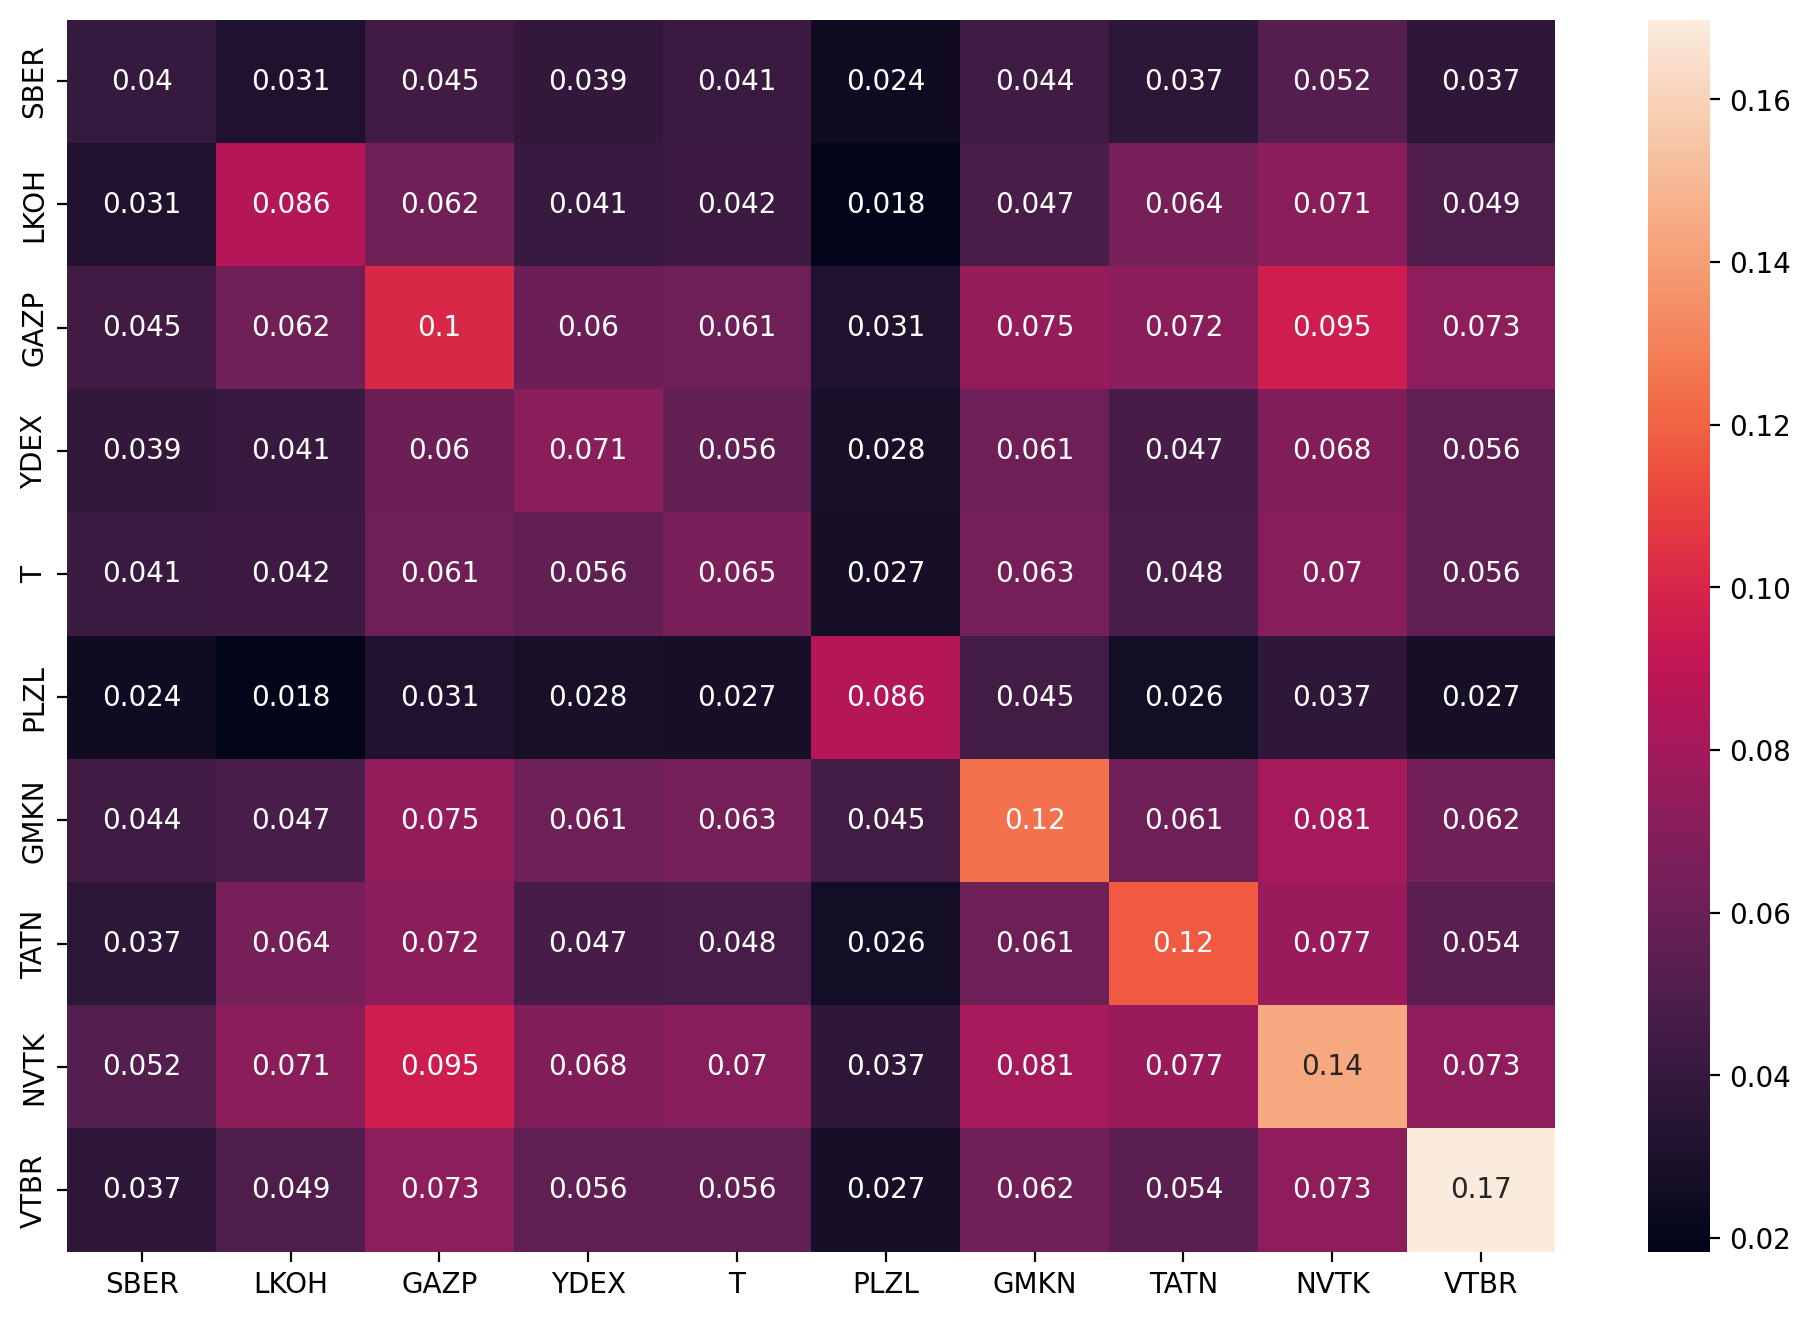

In [10]:
plt.figure(figsize=(12,8), dpi=200)
sns.heatmap(cov_mat, annot = True);

Можно заметить следующую особенность: никакие две акции не независимые, поэтому нигде в матрице ковариации нет 0.

Пока что говорить о том, какие акции брать надо в меньшем количестве, а какие - в большем, нельзя, поэтому продолжаем наше исследование.

## 5. Моделирование

Для того, чтобы построить **эффективную границу**, необходимо создать огромное количество случайных портфелей, для чего отлично подойдёт ***метод Монте-Карло***.

In [11]:
from Functions import calculate_weights

cons = ({'type' : 'eq', 'fun' : lambda x: np.sum(x) - 1}) #Накладываем ограничения
bounds = tuple((0,1) for _ in range(len(tickers))) #Задаём границы для веса
init_guess = [1/len(tickers)] * len(tickers) #Задаём начальную точку для минимизации

opt_results = calculate_weights(data, cons, bounds, init_guess)
print(opt_results)

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.18922871110635758
       x: [ 6.693e-01  1.320e-01  0.000e+00  0.000e+00  2.396e-17
            1.987e-01  6.722e-18  0.000e+00  0.000e+00  1.919e-17]
     nit: 10
     jac: [ 1.892e-01  1.892e-01  2.337e-01  1.950e-01  2.048e-01
            1.892e-01  2.364e-01  2.013e-01  2.714e-01  1.947e-01]
    nfev: 110
    njev: 10


Мы всё рассчитали и получили идеальные веса, теперь осталось это оформить для отчёта и посмотреть, сколько же конкретно денег мы должны вложить в каждую акцию.

## 6. Обработка результатов и построение графиков

In [12]:
resulting_data = pd.DataFrame(data=opt_results.x * 100, index=tickers, columns=['Вес %'])
resulting_data = resulting_data.round(2)
resulting_data

,Вес %
SBER,66.93
LKOH,13.20
GAZP,0.00
YDEX,0.00
T,0.00
PLZL,19.87
GMKN,0.00
TATN,0.00
NVTK,0.00
VTBR,0.00


Наше исследование показало, что лишь 3 акции из 10 предложенных должны быть куплены. Теперь доработаем нашу таблицу и построим графики. 

In [13]:
resulting_data['Вес в рублях'] = resulting_data['Вес %'] / 100 * 1_000_000
resulting_data = resulting_data[resulting_data['Вес %'] > 0.1]
resulting_data

,Вес %,Вес в рублях
SBER,66.93,669300.0
LKOH,13.20,132000.0
PLZL,19.87,198700.0


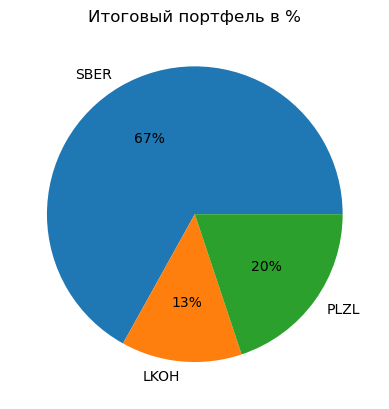

In [14]:
plt.pie(resulting_data['Вес %'], labels=['SBER', 'LKOH', 'PLZL'], autopct='%.0f%%')
plt.title('Итоговый портфель в %')
plt.savefig('Portfolio_Perc');

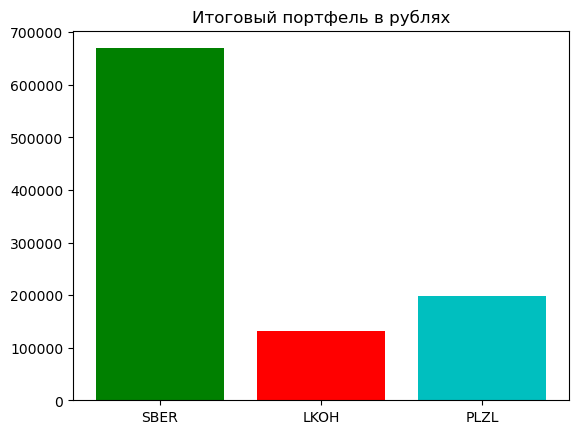

In [15]:
plt.bar(x=resulting_data.index, height=resulting_data['Вес в рублях'], color = ('g', 'r', 'c'))
plt.title('Итоговый портфель в рублях')
plt.savefig('Portfolio_Rubles');

In [16]:
resulting_data.to_excel('Оптимизированный портфель.xlsx')

## 7.Выводы
1. Проведённый анализ позволил увидеть, что оптимальный портфель состоит не из одной самой прибыльной акции. Доли распределены так, чтобы корреляция активов снижала общий риск.
2. Наибольшую доходность показывают акции "Сбербанка" (67%), следом идут акции "Полюса" (20%) и "Лукойла" (13%). Вполне логично, что "Полюс" набрал 20% - золото считается инструментом для защиты капитала в период экономической нестабильности и инфляции.